<a href="https://colab.research.google.com/github/coinblum01-wq/trucweb/blob/main/NguyenTrongTruc_2474802016707_Ontap2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Nguyễn Trọng Trúc - 2474802016707 - Ôn tập**

**PHẦN 1: TIỀN XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU**

**Cell 0 — Import thư viện (chạy đầu tiên)**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

***Câu 1: Nạp và Khám phá dữ liệu***

In [ ]:
# Tải bộ dữ liệu titanic tích hợp trong seaborn
df = sns.load_dataset('titanic')

# In 5 dòng đầu tiên
print("5 dòng đầu tiên của tập dữ liệu:")
display(df.head())

# In thông tin tổng quan
print("\nThông tin tổng quan của dữ liệu:")
df.info()

5 dòng đầu tiên của tập dữ liệu:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Thông tin tổng quan của dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


***Câu 2: Xử lý giá trị khuyết***

In [ ]:
# Đếm số lượng giá trị khuyết ở mỗi cột
print("Số lượng giá trị khuyết ở mỗi cột:")
print(df.isnull().sum())

# Xóa cột 'deck' vì quá nhiều giá trị khuyết
df = df.drop(columns=['deck'])

# Điền giá trị khuyết của cột 'age' bằng giá trị trung bình
df['age'] = df['age'].fillna(df['age'].mean())

# Kiểm tra lại
print("\nSố lượng giá trị khuyết sau khi xử lý:")
print(df.isnull().sum())

Số lượng giá trị khuyết ở mỗi cột:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Số lượng giá trị khuyết sau khi xử lý:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


***Câu 3: Phân tích và Trực quan hóa***

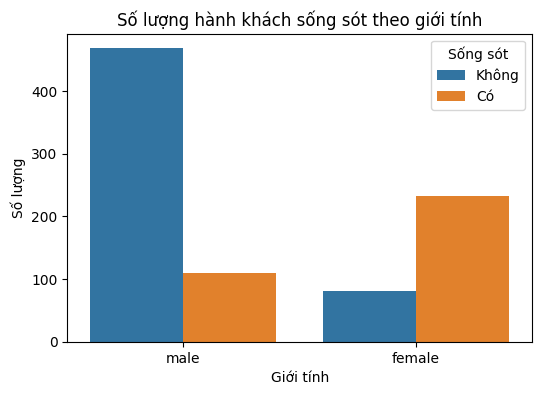

In [ ]:
# 3.1 Biểu đồ số lượng sống sót theo giới tính
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Số lượng hành khách sống sót theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.legend(title='Sống sót', labels=['Không', 'Có'])
plt.show()

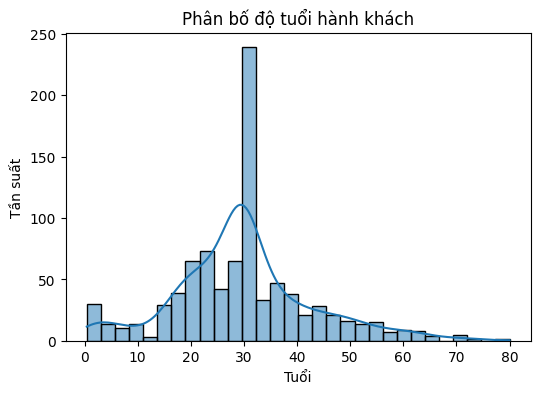

In [ ]:
# 3.2 Biểu đồ phân bố độ tuổi
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True, bins=30)
plt.title('Phân bố độ tuổi hành khách')
plt.xlabel('Tuổi')
plt.ylabel('Tần suất')
plt.show()

Ma trận tương quan:
          survived    pclass       age      fare
survived  1.000000 -0.338481 -0.069809  0.257307
pclass   -0.338481  1.000000 -0.331339 -0.549500
age      -0.069809 -0.331339  1.000000  0.091566
fare      0.257307 -0.549500  0.091566  1.000000


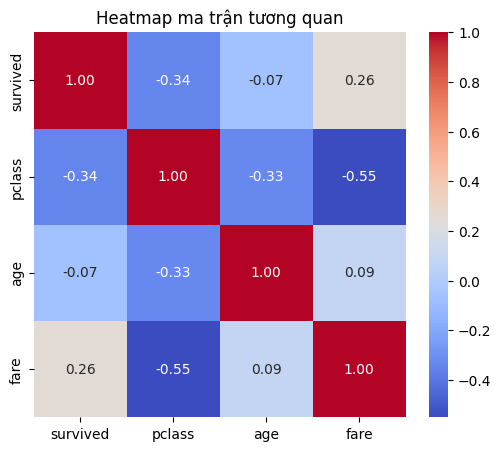

In [ ]:
# 3.3 Ma trận tương quan + Heatmap
numeric_cols = ['survived', 'pclass', 'age', 'fare']
corr_matrix = df[numeric_cols].corr()

print("Ma trận tương quan:")
print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap ma trận tương quan')
plt.show()

***Câu 4: Mã hóa dữ liệu***

In [ ]:
# 4.1 Label Encoding cho cột 'sex'
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# 4.2 One-Hot Encoding cho cột 'embarked'
embarked_dummies = pd.get_dummies(df['embarked'], prefix='embarked')
df = pd.concat([df, embarked_dummies], axis=1)

print("Dữ liệu sau khi mã hóa:")
display(df.head())

Dữ liệu sau khi mã hóa:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,False,False,True
1,1,1,1,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,True,False,False
2,1,3,1,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,1,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,0,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,False,False,True


**PHẦN 2: XÂY DỰNG MÔ HÌNH HỌC SÂU CƠ BẢN**

***Câu 5: Chuẩn bị dữ liệu cho Học sâu***

In [ ]:
# Tạo X, y
X = df[['pclass', 'sex', 'age']]
y = df['survived']

# Chia tập train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Kích thước tập train:", X_train_scaled.shape)
print("Kích thước tập test:", X_test_scaled.shape)

Kích thước tập train: (712, 3)
Kích thước tập test: (179, 3)


**Câu 6: Xây dựng mạng Nơ-ron nhân tạo (ANN)**

In [ ]:
# Khởi tạo mô hình Sequential
model = keras.Sequential()

# Lớp ẩn: 16 nơ-ron, activation relu, input_shape = số đặc trưng (3)
model.add(layers.Dense(16, activation='relu', input_shape=(3,)))

# Lớp đầu ra: 1 nơ-ron, activation sigmoid (phân loại nhị phân)
model.add(layers.Dense(1, activation='sigmoid'))

# Compile mô hình
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện mô hình 20 epochs
history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2313 - loss: 0.8593 - val_accuracy: 0.1389 - val_loss: 0.8295
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3719 - loss: 0.7618 - val_accuracy: 0.4444 - val_loss: 0.7225
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5266 - loss: 0.6893 - val_accuracy: 0.5833 - val_loss: 0.6409
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6625 - loss: 0.6323 - val_accuracy: 0.7500 - val_loss: 0.5755
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7453 - loss: 0.5876 - val_accuracy: 0.8194 - val_loss: 0.5190
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7766 - loss: 0.5518 - val_accuracy: 0.8750 - val_loss: 0.4715
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7969 - loss: 0.5240 - val_accuracy: 0.9167 - val_loss: 0.4361
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7828 - loss: 0.5046 - val_accuracy: 0.8750 - val_l

In [ ]:
# Đánh giá mô hình trên tập test
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nKết quả đánh giá trên tập test:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")


Kết quả đánh giá trên tập test:
Loss: 0.4473
Accuracy: 0.7933
